<a href="https://colab.research.google.com/github/ashreenn/complete_rag_systems/blob/main/embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

what are embeddings:
think of embeddings as a way to translate words into a language that computers understand- numbers!

In [ ]:
!pip install matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#simplified 2d example (real embeddingd have hundreds of dimensions)
word_embeddings={
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "dog":[0.7,0.3],
    "puppy":[0.65,0.35],
    "car":[-0.5,0.2],
    "truck":[-0.45,0.15]
}

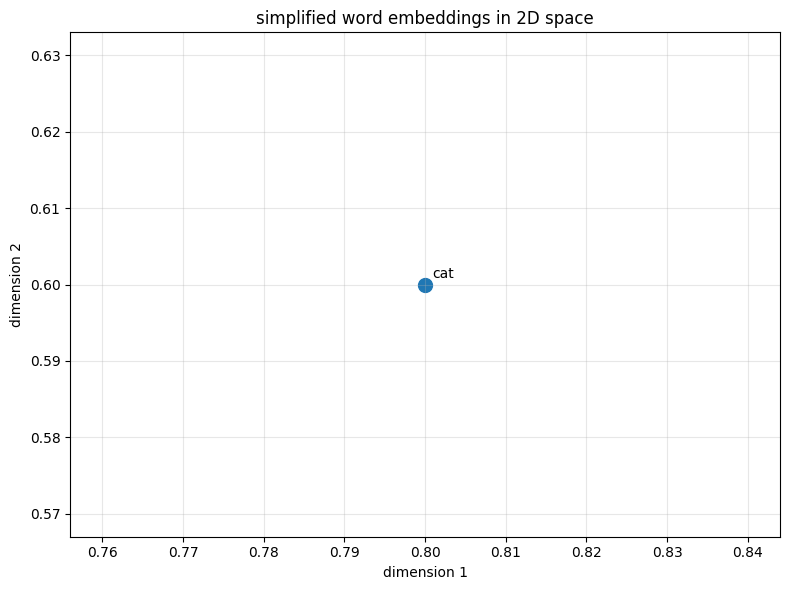

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
fig,ax=plt.subplots(figsize=(8,6))
#Creates a figure and plotting area with size 8×6.
for word,coords in word_embeddings.items():
  #Loops through each word and its vector coordinates from the dictionary.
  ax.scatter(coords[0],coords[1],s=100)
  #Plots each word as a point using x and y coordinates.
  ax.annotate(word,(coords[0],coords[1]), xytext=(5,5),
  textcoords='offset points')
  #Displays the word label near its plotted point.
  ax.set_xlabel('dimension 1')
  #Sets label for x-axis.
  ax.set_ylabel('dimension 2')
  #Sets label for y-axis.
  ax.set_title('simplified word embeddings in 2D space')
  #Adds title to the graph.
  ax.grid(True,alpha=0.3)
  #Adds light grid lines to the graph.
  plt.tight_layout()
  #Adjusts spacing to avoid overlap.
  plt.show()
  #Displays the final plot.

measuring similarity

In [ ]:
def cosine_similarity(vec1,vec2):
  """
  cosine similarity measures the angle between two vectors
  -result close to 1: very similar
  -result close to 0: not related
  -result close to -1: opposite meanings
  """

  dot_product=np.dot(vec1,vec2)
  norm_a=np.linalg.norm(vec1)
  norm_b=np.linalg.norm(vec2)
  return dot_product/(norm_a*norm_b)

In [ ]:
# This code creates a function called cosine_similarity that calculates how similar two vectors are.
# The docstring explains the meaning of cosine similarity values:
# close to 1 → vectors are very similar
# close to 0 → vectors are unrelated
# close to -1 → vectors are opposite
# np.dot(vec1, vec2) calculates the dot product of the two vectors.
# np.linalg.norm(vec1) finds the magnitude (length) of the first vector.
# np.linalg.norm(vec2) finds the magnitude (length) of the second vector.
# The return statement applies the cosine similarity formula and returns the similarity score.

In [ ]:
#example
cat_vector=[0.8,0.6,0.3]
kitten_vector=[0.75,0.65,0.35]
dog_vector=[-0.5,0.3,0.1]
cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [ ]:
# cat_vector, kitten_vector, and dog_vector are example vector representations of words.
# Similar words like "cat" and "kitten" have close vector values.
# cosine_similarity(cat_vector, kitten_vector) calculates how similar the two vectors are.
# The result is stored in cat_kitten_similarity.
# Since cat and kitten are related in meaning, the similarity score will be close to 1.
# print(cat_kitten_similarity) displays the similarity score between the two vectors.

In [ ]:
cosine_similarity(cat_vector,dog_vector)

np.float64(-0.30761416489327703)

creating your first embeddings

In [ ]:
!pip install langchain-huggingface
!pip install sentence-transformers
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 24.4 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [ ]:
#huggingface and openai models

from langchain_huggingface import HuggingFaceEmbeddings
#initialize a simple embedding model (no api key needed)
embeddings=HuggingFaceEmbeddings(
    model_name="#write your model name"
)
embeddings

In [ ]:
# from langchain_huggingface import HuggingFaceEmbeddings
# imports the HuggingFaceEmbeddings class from LangChain to generate embeddings using Hugging Face models.
# embeddings = HuggingFaceEmbeddings(...)
# creates an embedding model object.
# model_name="#write your model name"
# specifies which embedding model to use from Hugging Face.
# Example model names:
# "sentence-transformers/all-MiniLM-L6-v2"
# "BAAI/bge-small-en"
# "intfloat/e5-small"
# These models convert text into vectors/embeddings.
# No API key is needed because Hugging Face models can run locally.
# embeddings
# displays the created embedding model object.

In [ ]:
#create your first embeddingd
text="hello, I am learning about embeddings"
embedding=embeddings.embed_query(text)
print(f"text:{text}")
print(f"embedding length:{len(embedding)}")
print(embedding)


In [ ]:
# text="hello, I am learning about embeddings"
# stores the sentence in a variable called text.
# embedding = embeddings.embed_query(text)
# converts the text into a numerical vector (embedding) using the embedding model.
# The embedding contains many numbers representing the meaning/features of the sentence.
# print(f"text:{text}")
# prints the original text.
# print(f"embedding length:{len(embedding)}")
# prints the size/dimensions of the embedding vector.
# len(embedding) tells how many numerical values are present in the vector.
# print(embedding)
# prints the complete embedding vector (list of numbers).

In [ ]:
sentences=[
"the cat sat on the mat",
           "a feline rested on the rug",
           "the dog played in the yard",
           "elfjewojfoe"
]
embedding_sentence=embeddings.embed_documents(sentences)
print(embedding_sentence[0])
print(embedding_sentence[1])


In [ ]:
# sentences = [...]
# creates a list of multiple sentences.
# embeddings.embed_documents(sentences)
# converts all sentences into embeddings/vectors.
# Each sentence gets its own numerical vector representation.

# Similar sentences like:

# "the cat sat on the mat"
# "a feline rested on the rug"

# will usually have similar embeddings because their meanings are related.

# "the dog played in the yard" will have a different embedding because the meaning is different.
# "elfjewojfoe" is random text, so its embedding may not have meaningful similarity.
# embedding_sentence[0]
# accesses the embedding of the first sentence.
# embedding_sentence[1]
# accesses the embedding of the second sentence.
# print() displays those embedding vectors (lists of numbers).

advantage of the above is that we can use it without keys

**open ai embeddings**

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [ ]:
os.environ["OPEN_API_KEY"]=os.getenv("OPEN_API_KEY")

In [ ]:
from langchain_openai import openAIEmbeddings
embeddings=OpenAIEmbeddingd(model="#write your model name here")


In [ ]:
embeddings

In [ ]:
#single text embeddings
single_text="lamgchain and rag are amazing frameworks and projects to work on"
single_embeddings=embeddings.embed_query(single_text)
print(len(single_embeddings))
print(single_embeddings)

In [ ]:
# single_text = "langchain and rag are amazing frameworks and projects to work on" stores a sentence in the variable single_text.
# embeddings.embed_query(single_text) converts the text into a numerical embedding/vector.
# The generated embedding is stored in single_embeddings.
# The embedding contains many numerical values representing the meaning of the sentence.
# print(len(single_embeddings)) prints the number of dimensions/values in the embedding vector.
# print(single_embeddings) displays the complete embedding vector.

In [ ]:
print("single text embeddings:")
print(f"input:{single_text}")
print(f"output: vector of {len(single_embeddings)} dimensions")
print(f"sample values: {single_embeddings[:5]}")

In [ ]:
# print("single text embeddings:") prints the heading/message.
# print(f"input:{single_text}") displays the original input text stored in single_text.
# len(single_embeddings) calculates the total number of dimensions/values in the embedding vector.
# print(f"output: vector of {len(single_embeddings)} dimensions") prints the size of the embedding vector.
# single_embeddings[:5] takes the first 5 values from the embedding vector.
# print(f"sample values: {single_embeddings[:5]}") displays sample numerical values from the embedding.

In [ ]:
multiple_texts=["ejflewjgo2;gpw;p","foefup32ifp2ip","kehlewhl","eljewogjw"]

In [ ]:
multiple_embeddings=embeddings.embed_documents(multiple_texts)

In [ ]:
multiple_embeddings

In [ ]:
print("\n multiple text embeddings:")
print(f"no. of texts:{len(multiple_texts)}")
print(f"no. of embeddings:{len(multiple_embeddings)}")
print(f"each embedding size:{len(multiple_embeddings[0])}")

In [ ]:
multiple_embeddings[1]

cosine similarity with openAI embeddings

In [ ]:
#example
sentences=[
    "wfjlwjfloqwjlo",
    "fowlfjlowjflwjl",
    "gkehlgjwelgjlow",
    "fvaelsfhvlawhvkk"
]

In [ ]:
import numpy as np
def cosine_similarity(vec1,vec2):
  dot_product=np.dot(vec1,vec2)
  norm_a=np.linalg.norm(vec1)
  norm_b=np.linalg.norm(vec2)
  return dot_product/(norm_a*norm_b)

In [ ]:
# import numpy as np imports the NumPy library and gives it the short name np.
# def cosine_similarity(vec1, vec2): creates a function to calculate similarity between two vectors.
# np.dot(vec1, vec2) calculates the dot product of the vectors.
# np.linalg.norm(vec1) finds the magnitude (length) of the first vector.
# np.linalg.norm(vec2) finds the magnitude (length) of the second vector.
# return dot_product/(norm_a*norm_b) applies the cosine similarity formula and returns the similarity score.

In [ ]:
from langchain_openai import openAIEmbeddings
embeddings=OpenAIEmbeddingd(model="")
embeddings

In [ ]:
sentence_embeddings=embeddings.embed_documents(sentences)
sentence_embeddings

In [ ]:
#calculate the similarity between all the pairs
for i in range(len(sentences)):
  for j in range(i+1,len(sentences)):
    similarity=cosine_similarity(sentence_embeddings[i],sentence_embeddings[j])
    print(f"'{sentences[i]}' vs '{sentences[j]}'")
    print(f"similarity:{similarity:.3f}\n")

In [ ]:
# for i in range(len(sentences)): loops through all sentences using their indexes.
# for j in range(i+1, len(sentences)): compares each sentence with the remaining sentences and avoids duplicate comparisons.
# cosine_similarity(sentence_embeddings[i], sentence_embeddings[j]) calculates similarity between two sentence embeddings.
# The similarity score is stored in the variable similarity.
# print(f"'{sentences[i]}' vs '{sentences[j]}'") displays the pair of sentences being compared.
# print(f"similarity:{similarity:.3f}\n") prints the similarity score up to 3 decimal places.
# Higher similarity values mean the sentence meanings are more related.

In [ ]:
#example-semantic search--retrieve similar sentences
#test semantic search
documens=[

     "I love learning artificial intelligence",
    "Machine learning is a part of AI",
    "Dogs are playing in the park",
    "The weather is very pleasant today"

]
query="what do i love?"



In [ ]:
def semantic_Search(query,documents,embeddings_models,top_k=3):
  """simple semantic search implementation"""
  #embed query and document
  query_embedding=embeddings_models.embed_query(query)
  doc_embeddings=embeddings_models.embed_documents(documents)
  #calculate similarity score
  similarities=[]
  for i,doc_emb in enumerate(doc_embeddings):
    similarity=cosine_similarity(query_embedding,doc_emb)
    similarities.append((similarity,documents[i]))

  #sort by similarity
  similarities.sort(reverse=True)
  return similarities[:top_k]


In [ ]:
# def semantic_Search(query,documents,embeddings_models,top_k=3): creates a function for semantic search.
# query is the user search text, documents is the list of documents, embeddings_models is the embedding model, and top_k=3 means returning the top 3 most similar results.
# embed_query(query) converts the search query into an embedding/vector.
# embed_documents(documents) converts all documents into embeddings.
# similarities=[] creates an empty list to store similarity scores and documents.
# for i, doc_emb in enumerate(doc_embeddings): loops through all document embeddings one by one.
# cosine_similarity(query_embedding, doc_emb) calculates similarity between the query and each document.
# similarities.append((similarity, documents[i])) stores the similarity score along with its document.
# similarities.sort(reverse=True) sorts documents from highest similarity to lowest.
# return similarities[:top_k] returns the top most similar documents.

In [ ]:
results=semantic_search(query,documents,embeddings)
results

In [ ]:
# semantic_search(query, documents, embeddings) calls the semantic search function.
# query is converted into an embedding/vector.
# documents are also converted into embeddings.
# Cosine similarity is calculated between the query embedding and each document embedding.
# Documents are ranked based on similarity scores.
# The top matching results are returned.
# results = ... stores those similar documents and their scores in the variable results.
# results displays the final semantic search output.